# Разведочный анализ через pygwalker

Визуальная разведка перед тем как фиксировать гипотезы для двух основных исследований (ABC/XYZ по товарам, RFM и когорты по клиентам). Часть структурных особенностей данных уже была известна, они не переоткрываются здесь заново а учитываются при выборе что смотреть.

Виджеты `pyg.walk()` ниже рендерятся только в живой Jupyter-сессии. На GitHub в этих ячейках будет пусто, смотреть нужно локально: `jupyter lab analysis/00_pygwalker_eda.ipynb`.

In [2]:
import sys
for p in (".", ".."):
    if p not in sys.path:
        sys.path.insert(0, p)

import pandas as pd
from sqlalchemy import create_engine

from scripts.common import config

engine = create_engine(
    f"postgresql+psycopg2://{config.POSTGRES_USER}:{config.POSTGRES_PASSWORD}"
    f"@{config.POSTGRES_HOST}:{config.POSTGRES_PORT}/{config.POSTGRES_DB}"
)

## Транзакции (выборка)

30 случайных дат из `staging.stg_sales`, около 150 тысяч строк.

In [3]:
df_txn = pd.read_sql(
    """
    select *
    from staging.stg_sales
    where source_date in (
        select source_date
        from (select distinct source_date from staging.stg_sales) t
        order by random()
        limit 30
    )
    """,
    engine,
)
df_txn.shape

(135544, 12)

In [ ]:
import pygwalker as pyg

pyg.walk(df_txn)

## Товары

Вся `marts.mart_product_performance`, 50 тысяч строк.

In [4]:
df_products = pd.read_sql("select * from marts.mart_product_performance", engine)
df_products.shape

(50000, 9)

In [ ]:
pyg.walk(df_products)

## Клиенты (выборка)

50 тысяч случайных клиентов из `marts.mart_customer_activity`.

In [6]:
df_customers = pd.read_sql(
    "select * from marts.mart_customer_activity order by random() limit 50000",
    engine,
)
df_customers.shape

(50000, 8)

In [ ]:
pyg.walk(df_customers)

## Продажи по дням

Вся `marts.mart_daily_sales`, посуточная динамика за всю историю.

In [8]:
df_daily = pd.read_sql("select * from marts.mart_daily_sales order by source_date", engine)
df_daily.shape

(1621, 7)

In [ ]:
pyg.walk(df_daily)

## Ставка скидки на позицию

Находка прошлой недели: `discount_per_item / price_per_item` распределена равномерно от 0 до 1, а не сосредоточена вокруг типичных для ритейла 10-30%. Проверка на выборке транзакций выше.

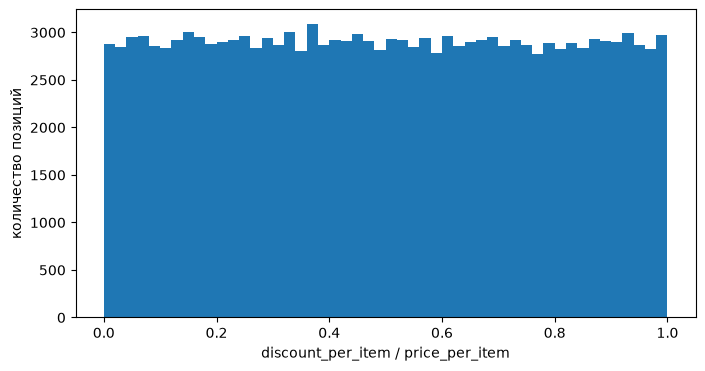

In [10]:
import matplotlib.pyplot as plt

discount_rate = df_txn["discount_per_item"] / df_txn["price_per_item"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(discount_rate, bins=50)
ax.set_xlabel("discount_per_item / price_per_item")
ax.set_ylabel("количество позиций")
plt.show()

## Что учитывать дальше

Скидка на позицию распределена равномерно от 0 до 100% от цены, это подтверждено и SQL-проверками и графиком выше. Для эластичности спроса к скидке это значит, что реальной зависимости, скорее всего, не найдётся: скидка не сигнал, а шум.

Выручка по товарам (`mart_product_performance`) распределена ближе к колоколообразной форме, чем к длинному хвосту. Классический Парето-скос 80/20 для ABC-анализа в этих данных под вопросом.

`client_id` берётся из пула примерно в миллион значений, который почти полностью исчерпан уже к 2023 году. Для когортного анализа это означает что новые когорты после 2023 года будут маленькими из-за исчерпания пула.

`gender` не привязан к клиенту: у одного и того же `client_id` в разных транзакциях встречаются оба значения. Для RFM-сегментации это поле не годится как признак клиента.

`purchase_date` из payload API не всегда совпадает с `source_date` (расхождение иногда в месяцы). Для RFM и когорт даты нужно считать по `source_date`, не по `purchase_date`.